In [1]:
# CELL 1 — Load Data + Preprocessing

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

df = pd.read_csv("../data/processed_diamonds.csv")

# IDEAL clustering features (price removed)
IDEAL_FEATURES = ["carat", "cut", "color", "clarity", "depth", "table", "y", "z", "volume"]

# Keep only the features that exist
features = [f for f in IDEAL_FEATURES if f in df.columns]

missing = [f for f in IDEAL_FEATURES if f not in df.columns]
if missing:
    print("⚠ Missing features:", missing)

X = df[features].copy()

# Identify categorical & numerical
cat_cols = [col for col in ["cut","color","clarity"] if col in features]
num_cols = [col for col in features if col not in cat_cols]

# Ordinal Encoding
cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_cat = pd.DataFrame(
    encoder.fit_transform(X[cat_cols]),
    columns=cat_cols,
    index=X.index
)

# Standard Scaling
scaler = StandardScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

# Final processed dataset
X_processed = pd.concat([X_num, X_cat], axis=1)

print("Processed Clustering Shape:", X_processed.shape)

# Save encoders for Streamlit
joblib.dump(encoder, "../models/cluster_encoder.pkl")
joblib.dump(scaler, "../models/cluster_scaler.pkl")
print("✔ Encoder & Scaler saved!")


Processed Clustering Shape: (46530, 9)
✔ Encoder & Scaler saved!


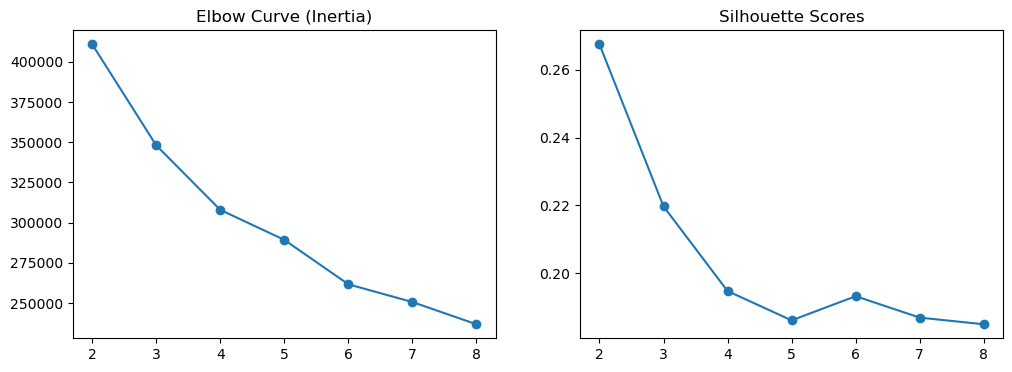

✔ Optimal K = 2
Final Silhouette Score: 0.2675
✔ KMeans model saved!


In [2]:
# CELL 2 — Elbow + Silhouette + Final Model

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 9)
inertia_list = []
silhouette_list = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_processed)
    
    inertia_list.append(km.inertia_)
    score = silhouette_score(X_processed, labels)
    silhouette_list.append(score)

# PLOTS
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Curve (Inertia)")

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_list, marker='o')
plt.title("Silhouette Scores")
plt.show()

# Choose k automatically = max silhouette score
K_OPTIMAL = K_range[np.argmax(silhouette_list)]
print("✔ Optimal K =", K_OPTIMAL)

# Final model
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_processed)
df["cluster"] = labels

score = silhouette_score(X_processed, labels)
print("Final Silhouette Score:", round(score,4))

# Save model
joblib.dump(kmeans, "../models/clustering_model.pkl")
print("✔ KMeans model saved!")


In [3]:
# CELL 3 — Cluster Profiling + Naming

df_temp = df.copy()

# Decode categorical values correctly
df_temp[cat_cols] = encoder.inverse_transform(X_cat)

cluster_summary = df_temp.groupby("cluster").agg({
    "price_inr":"mean",
    "carat":"mean",
    "volume":"mean",
    "cut": lambda x: x.mode()[0],
    "clarity": lambda x: x.mode()[0]
}).sort_values("price_inr", ascending=False)

print("Cluster Profile:")
print(cluster_summary.round(2))

# Auto cluster-naming logic
cluster_names = {}

for cid, row in cluster_summary.iterrows():
    if row["carat"] > df["carat"].quantile(0.75) and row["price_inr"] > df["price_inr"].quantile(0.75):
        name = "Premium Heavy Diamonds"
    elif row["carat"] < df["carat"].quantile(0.25):
        name = "Affordable Small Diamonds"
    elif row["cut"] in ["Premium","Ideal"] and row["clarity"] in ["VVS1","VVS2","IF"]:
        name = "Luxury Ideal Diamonds"
    else:
        name = "Mid-range Diamonds"
    
    cluster_names[cid] = name

print("\nAssigned Cluster Names:")
print(cluster_names)

df["cluster_name"] = df["cluster"].map(cluster_names)

joblib.dump(cluster_names, "../models/cluster_names.pkl")
print("✔ Cluster names saved!")
df[["cluster","cluster_name","carat","price_inr"]].sample(10)


Cluster Profile:
         price_inr  carat  volume    cut clarity
cluster                                         
0            12.86   0.70    5.09  Ideal     SI1
1            11.38   0.35    4.20  Ideal     VS2

Assigned Cluster Names:
{0: 'Mid-range Diamonds', 1: 'Mid-range Diamonds'}
✔ Cluster names saved!


,cluster,cluster_name,carat,price_inr
16373,0,Mid-range Diamonds,0.993252,13.324072
43364,0,Mid-range Diamonds,0.530628,12.169310
43373,1,Mid-range Diamonds,0.425268,12.169751
163,0,Mid-range Diamonds,0.536493,12.371422
10735,0,Mid-range Diamonds,0.779325,12.977294
32473,1,Mid-range Diamonds,0.336472,11.399208
6340,0,Mid-range Diamonds,0.703098,12.775684
19601,0,Mid-range Diamonds,0.993252,13.595787
7244,0,Mid-range Diamonds,0.783902,12.816439
42806,1,Mid-range Diamonds,0.488580,12.128360


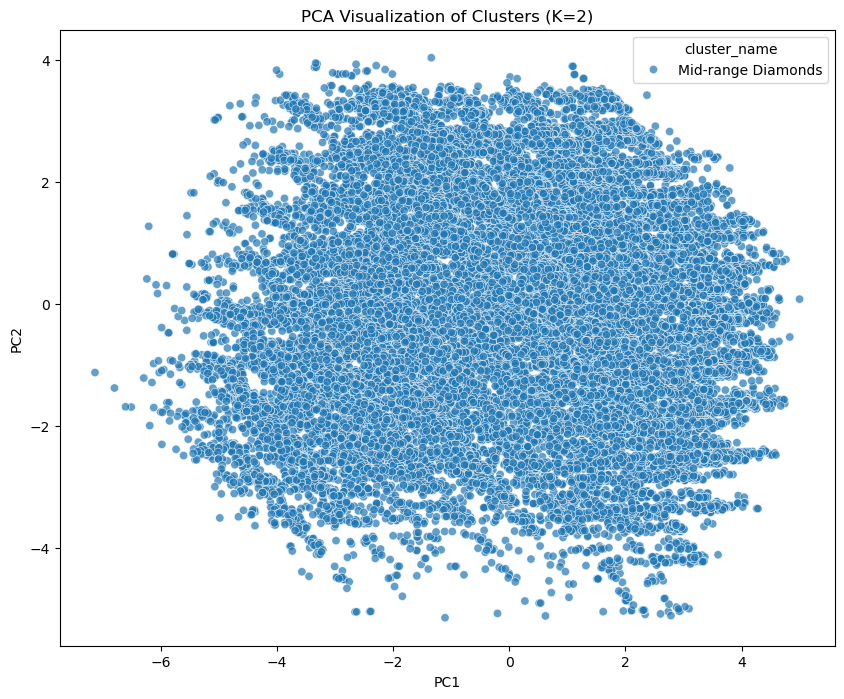

In [4]:
# CELL 4 — PCA Visualization

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_vals = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(pca_vals, columns=["PC1","PC2"])
pca_df["cluster_name"] = df["cluster_name"]

plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="cluster_name", palette="tab10",
    alpha=0.7
)
plt.title(f"PCA Visualization of Clusters (K={len(cluster_names)})")
plt.show()
